In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm, N,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
L = 5000 
number_floors = 10
floor_height = 3500
H = floor_height * number_floors
B = 350

lc = 500

output_path = os.getcwd()
mesh_name = 'sw_00'
output_file = os.path.join(output_path, mesh_name + '.msh')
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)
# Create points for each floor level
# Bottom points
points_left = [gmsh.model.geo.addPoint(0, 0, 0, lc)]  # p1
points_center = [gmsh.model.geo.addPoint(L/2, 0, 0, lc)]  # p5
points_right = [gmsh.model.geo.addPoint(L, 0, 0, lc)]  # p2
# Create points at each floor level
for i in range(1, number_floors + 1):
    y = i * floor_height
    points_left.append(gmsh.model.geo.addPoint(0, y, 0, lc))
    points_center.append(gmsh.model.geo.addPoint(L/2, y, 0, lc))
    points_right.append(gmsh.model.geo.addPoint(L, y, 0, lc))
# Create horizontal and vertical lines for each floor
surfaces_left = []
surfaces_right = []
bottom_lines = []  # Store bottom lines for supports
floor_top_lines = []  # Store top lines of each floor for distributed loads

for i in range(number_floors):
    # Horizontal lines (bottom and top of each floor)
    h_bottom_left = gmsh.model.geo.addLine(points_left[i], points_center[i])
    h_bottom_right = gmsh.model.geo.addLine(points_center[i], points_right[i])
    h_top_left = gmsh.model.geo.addLine(points_left[i+1], points_center[i+1])
    h_top_right = gmsh.model.geo.addLine(points_center[i+1], points_right[i+1])
    
    # Save bottom lines only for first floor (i==0)
    if i == 0:
        bottom_lines.extend([h_bottom_left, h_bottom_right])
    
    # Save top lines of each floor for distributed loads
    floor_top_lines.extend([h_top_left, h_top_right])
    
    # Vertical lines
    v_left = gmsh.model.geo.addLine(points_left[i], points_left[i+1])
    v_center = gmsh.model.geo.addLine(points_center[i], points_center[i+1])
    v_right = gmsh.model.geo.addLine(points_right[i], points_right[i+1])
    
    # Create surfaces for left half
    curve_loop_left = gmsh.model.geo.addCurveLoop([h_bottom_left, v_center, -h_top_left, -v_left])
    surface_left = gmsh.model.geo.addPlaneSurface([curve_loop_left])
    surfaces_left.append(surface_left)
    
    # Create surfaces for right half
    curve_loop_right = gmsh.model.geo.addCurveLoop([h_bottom_right, v_right, -h_top_right, -v_center])
    surface_right = gmsh.model.geo.addPlaneSurface([curve_loop_right])
    surfaces_right.append(surface_right)
# Synchronize the model
gmsh.model.geo.synchronize()
# Create physical groups for all surfaces
all_surfaces = surfaces_left + surfaces_right
gmsh.model.addPhysicalGroup(2, all_surfaces, 201)
gmsh.model.setPhysicalName(2, 201, "Wall")
# Supports at entire bottom line (y=0) - NOW AS LINES
gmsh.model.addPhysicalGroup(1, bottom_lines, 101)
gmsh.model.setPhysicalName(1, 101, "Support_base")
# LOADS SECTION
# Pload_lateral at top left corner (x=0, y=H)
gmsh.model.addPhysicalGroup(0, [points_left[-1]], 301)
gmsh.model.setPhysicalName(0, 301, "Pload_lateral")
# Distributed vertical loads on top lines of each floor
gmsh.model.addPhysicalGroup(1, floor_top_lines, 302)
gmsh.model.setPhysicalName(1, 302, "Pload_vertical_distributed")
# Synchronize the model
gmsh.model.geo.synchronize()
def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
    
all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)

In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Define material
fc_21 = Material(name='fc_21',
                 E=19185.1,
                 nu=0.20,
                 rho= 2400*kg/m**3*g*0)

# Define membrane section
ConcreteWall = Membrane(name='ConcreteWall',
                        thickness=B,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteWall}

# Define distributed load magnitude  {physical_id: [x load, y load]}
Pload_vertical = 411879.31/5000/B
Pload_lateral = 98066.5*2

load_dictionary = {
    302: {'value': Pload_vertical, 'direction': '-y'},   
    301: {'value': Pload_lateral,  'direction': 'x'},  
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       }

# Define self-weight (not used)
self_weight = [0, 0]

In [8]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (1143 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      2500.0000         0.0000         0.0000
       3      5000.0000         0.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     301      0   'Pload_lateral'
     101      1   'Support_base'
     302      1   'Pload_vertical_distributed'
     201      2   'Wall'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     301      0       15   

In [9]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Build FEM model — applies BCs, builds elements, assembles load vector
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = element_map,
    analysis_type       = 'planeStress',
    consistent_loads    = True,
    sampling_points     = 3,

    verbose=True,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : planeStress
  Nodes            : 1143
  system_nDof      : 2286
  Elements         : 960
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---
  [201] Wall                  t=350  E=19185.10  nu=0.200

  --- Restrained nodes ---
  Node      1  [0. 0.]                         ['r', 'r']
  Node      2  [2500.    0.]                   ['r', 'r']
  Node      3  [5000.    0.]                   ['r', 'r']
  Node     34  [416.666667   0.      ]         ['r', 'r']
  Node     35  [833.333333   0.      ]         ['r', 'r']
  Node     36  [1250.    0.]                   ['r', 'r']
  Node     37  [1666.666667    0.      ]       ['r', 'r']
  Node     38  [2083.333333    0.      ]       ['r', 'r']
  Node     39  [2916.666667    0.      ]       ['r', 'r']
  Node     40  [3333.333333    0.      ]       ['r', 'r']
  Node     41  [3750.    0.]                   ['r', 'r'

In [10]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 1143
  system_nDof      : 2286
  Elements         : 960
  Physical groups  : 4

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
     301     0  Pload_lateral                  1         1  N/A
     101     1  Support_base                  12        13  N/A
     302     1  Pload_vertical_distributed         120       130  N/A
     201     2  Wall                         960      1143  OK

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
       1        0.0000        0.0000  ['r', 'r']
       2     2500.0000        0.0000  ['r', 'r']
       3     5000.0000        0.0000  ['r', 'r']
      34      416.6667        0.0000  ['r', 'r']
  

In [11]:
# Solve — single step
model.solve_static(
    n_steps=1, 
    load_factor=1.0,
    verbose = True,
)


  SOLVE SUMMARY
--------------------------------------------------------------------------------
  Steps solved     : 1
  Last load factor : 1.0000
  Max |ux|         : 94.428615
  Max |uy|         : 16.702117
  Max Von Mises    : 18.3714

  --- Equilibrium ---
  Applied  Fx: +196133.0000   Reaction Rx: -196133.0000   Balance: -2.7096e-07
  Applied  Fy: -4118793.1000   Reaction Ry: +4118793.1000   Balance: -1.5507e-07
--------------------------------------------------------------------------------



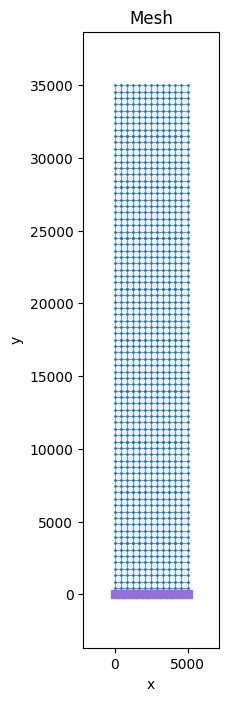

In [12]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

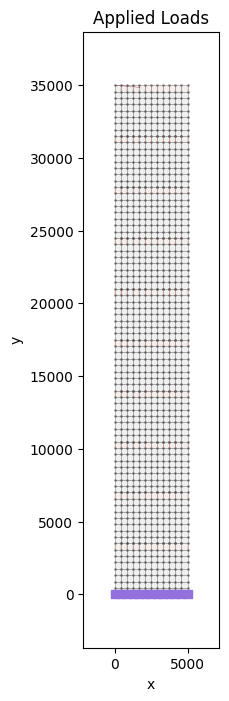

In [13]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

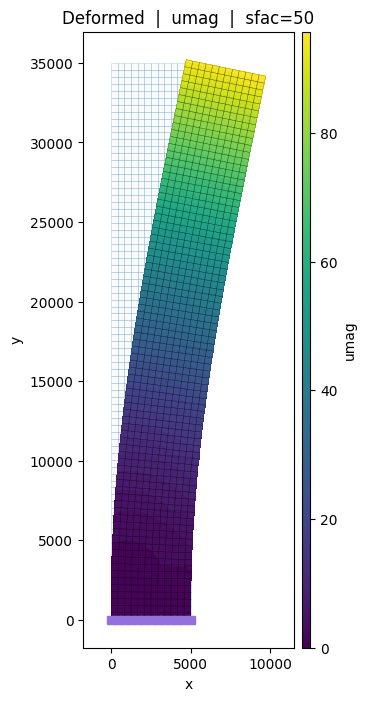

In [14]:
# Plot deformed
model.plot_deformed(
    sfac                = 50,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

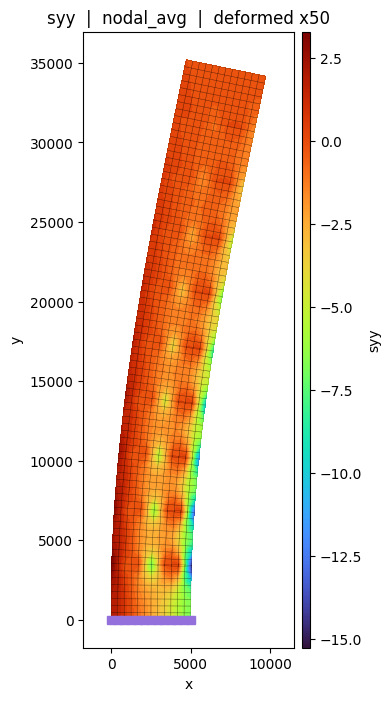

In [15]:
# Plot field
model.plot_field(
    component           = 'syy',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

## Opensees

In [16]:
import openseespy.opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)

In [17]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [18]:
# Boundary conditions
constrained_nodes = set()

for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            if tag not in constrained_nodes:
                constrained_nodes.add(tag)
                ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [19]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               fc_21.E,
               fc_21.nu,
               fc_21.rho)

In [20]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('quad', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)
        # ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

<Axes: >

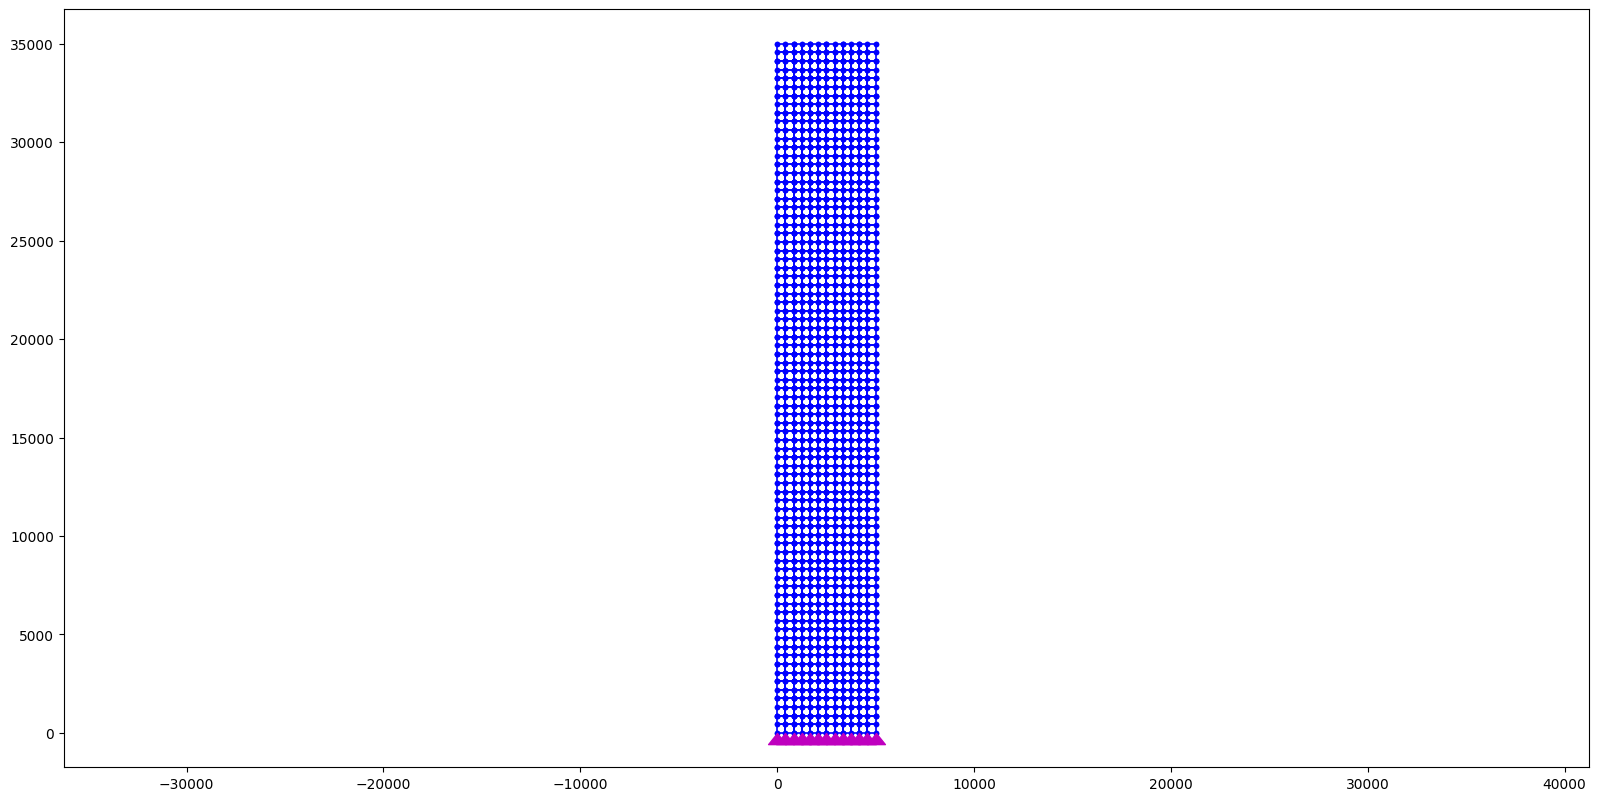

In [21]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [22]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

for tag, force in model.F_nodal.items():
    if np.any(np.abs(force) > 0):
        ops.load(tag, *force.tolist())

In [23]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

after: 100 iterations  current Norm: 1.29655e-06 (max: 1e-06, Norm deltaX: 2.0447e-12)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 9 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag


-3

In [24]:
# save last step
model.set_results_opensees(ops, step=0, time=1.0)

FEMResult(step=0, time=1.0000)

In [30]:
# Static results in gmsh — last step
model.plot2gmsh(
    step           = -1,
    source         = 'opensees',
    disp_factor    = 50,
    show_disp      = True,
    show_loads     = True,
    show_reactions = True,
    show_stress    = True,
    show_strain    = True,
    show_vm        = True,
    show_averaged  = True,
)

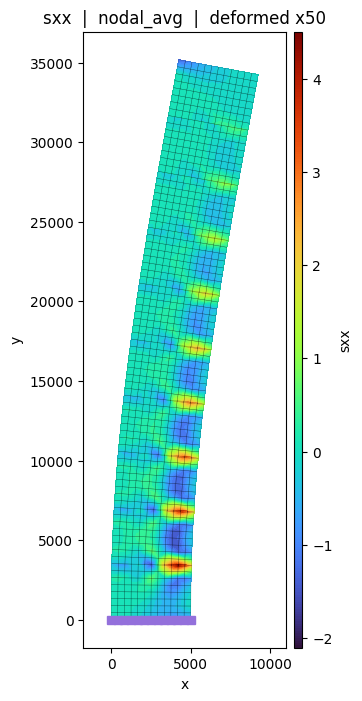

In [26]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'opensees',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

In [27]:
# What's in the model
print(repr(model))
print(f"\nFEM steps     : {len(model.results_fem)}")
print(f"OpenSees steps: {len(model.results_opensees)}")
print(f"Modal modes   : {len(model.results_opensees_modal) if hasattr(model, 'results_opensees_modal') else 0}")

# Modal summary
if hasattr(model, 'results_opensees_modal'):
    print(f"\n  {'Mode':>6}  {'Freq [Hz]':>12}  {'Period [s]':>12}")
    for mr in model.results_opensees_modal:
        print(f"  {mr.mode:>6}  {mr.freq:>12.4f}  {mr.period:>12.4f}")

FEMModel | nodes=1143 | elements=960 | steps_fem=1 | steps_opensees=1 | analysis=planeStress

FEM steps     : 1
OpenSees steps: 1
Modal modes   : 0


In [28]:
# Node comparison — FEM vs OpenSees at (1000, 500)
model.get_node(x=5000, y=35000, source='fem',      step=-1)
model.get_node(x=5000, y=35000, source='opensees', step=-1)



  NODE RESULTS  (step=-1)
------------------------------------------------------------
     Tag  Coordinates                               ux            uy
  ------  ------------------------------  ------------  ------------
      33  [ 5000. 35000.]                   +94.260263    -16.702117
------------------------------------------------------------

  NODE RESULTS  (step=-1)
------------------------------------------------------------
     Tag  Coordinates                               ux            uy
  ------  ------------------------------  ------------  ------------
      33  [ 5000. 35000.]                   +84.834236    -15.031906
------------------------------------------------------------


{'tag': 33,
 'coordinates': array([ 5000., 35000.]),
 'u': array([ 84.834236, -15.031906]),
 'restrain': array(['f', 'f'], dtype='<U1')}

Text(0.5, 1.0, 'syy')

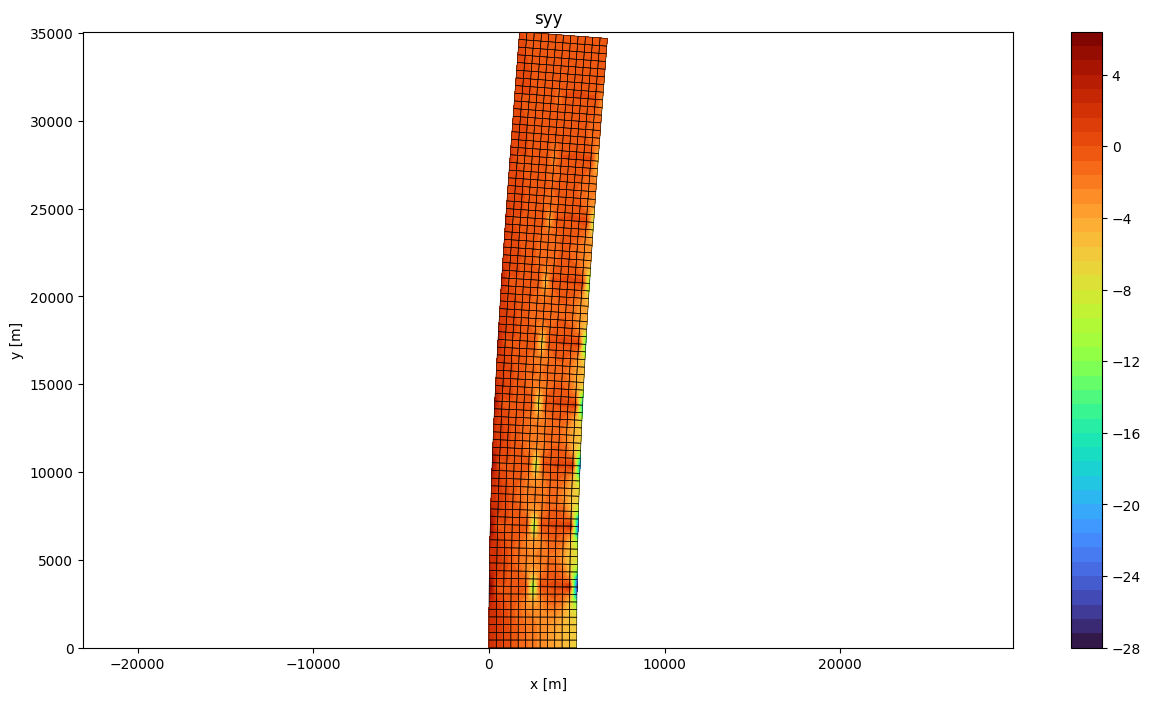

In [29]:
# jstr = 'sxx'
jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')